In [32]:
import pandas as pd
import glob
import os
from os.path import isfile, join
from os import listdir
import numpy as np
from sklearn.model_selection import train_test_split
import missingno as msno
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import sklearn


### Load, change data format, rename, split

In [33]:
repo_path = os.getcwd()
folder_path = (os.path.join(repo_path, 'ING Hubs Data-20260415T182244Z-3-001/ING Hubs Data'))
source_files_path = os.path.join(folder_path, 'CS')
dataframes = []

for file in listdir(source_files_path):
    print(f"Processing file: {os.path.join(source_files_path, file)}")
    # df = pd.read_csv(os.path.join(source_files_path, file), sep=';', on_bad_lines='skip')  
    df = pd.read_csv(os.path.join(source_files_path, file), sep=';')  
    dataframes.append(df)

df = pd.concat(dataframes, ignore_index=True)

file_name = 'raw_data_full.csv'
save_path = os.path.join(folder_path, file_name)

if os.path.exists(save_path):
    os.remove(save_path)
    print(f"Rewriting '{file_name}' file")
else:
    print(f"No existing file found. Creating '{file_name}' for the first time.")
df.to_csv(save_path, index=False, sep=';')

print(df.head(10))

Processing file: c:\Users\ydmar\Documents\UW\UW4 semester\UB_CRM_2026\ING Hubs Data-20260415T182244Z-3-001/ING Hubs Data\CS\CS1.csv


C:\Users\ydmar\AppData\Local\Temp\ipykernel_15780\1559358964.py:9: DtypeWarning: Columns (2,3,4,9,10,11,12,15,17,18,19,20,21,22,23,25,27,30,31,33,35,37,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(source_files_path, file), sep=';')


Processing file: c:\Users\ydmar\Documents\UW\UW4 semester\UB_CRM_2026\ING Hubs Data-20260415T182244Z-3-001/ING Hubs Data\CS\CS2.csv


C:\Users\ydmar\AppData\Local\Temp\ipykernel_15780\1559358964.py:9: DtypeWarning: Columns (2,4,7,9,10,15,17,18,22,23,25,33,37,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(source_files_path, file), sep=';')


Processing file: c:\Users\ydmar\Documents\UW\UW4 semester\UB_CRM_2026\ING Hubs Data-20260415T182244Z-3-001/ING Hubs Data\CS\cs3.csv


C:\Users\ydmar\AppData\Local\Temp\ipykernel_15780\1559358964.py:9: DtypeWarning: Columns (2,4,9,10,11,13,15,17,21,22,23,25,27,33,35,37,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(source_files_path, file), sep=';')


Processing file: c:\Users\ydmar\Documents\UW\UW4 semester\UB_CRM_2026\ING Hubs Data-20260415T182244Z-3-001/ING Hubs Data\CS\cs4.csv


C:\Users\ydmar\AppData\Local\Temp\ipykernel_15780\1559358964.py:9: DtypeWarning: Columns (2,3,4,7,9,10,11,12,13,15,17,18,19,20,21,22,23,27,30,31,35,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(source_files_path, file), sep=';')


Rewriting 'raw_data_full.csv' file
         ID    obs_date              Var_01              Var_02  \
0   6311599  2020-12-31       122250.264804       131926.535026   
1  25934835  2015-12-31       388979.543365       428155.215523   
2  70390679  2019-12-31    1489136519.61685    1520699893.50543   
3  70390679  2020-12-31      1523974223.618    1549976390.42182   
4  70390679  2016-12-31    1795857407.75616    1796012059.89858   
5  70390679  2017-12-31    1923124362.20889    1923416807.43042   
6  70390679  2018-12-31    2004641600.60354    2004808106.29287   
7  58426402  2015-12-31  28426418710.238602  94177077753.491699   
8  70139609  2015-12-31    627133992.151987    871193900.219826   
9  70139609  2019-12-31    1438217006.32025     1595835271.3624   

             Var_03    Var_04    Var_05            Var_06    Var_07  \
0      84378.268488  4.452988 -0.573123       5392.171833  0.146342   
1      57139.405376  1.517365  0.894176      10317.386614  0.056952   
2             

In [34]:
mapping_df = pd.read_excel(os.path.join(folder_path,'description of variables 1.xlsx'))   
print(mapping_df)

      Column                                        Description
0         ID                                        Customer ID
1   obs_date  observation date when financial data are observed
2     Var_01                               Assets Current Total
3     Var_02                                       Assets Total
4     Var_03                          Cash And Cash Equivalents
5     Var_04                                      Current Ratio
6     Var_05                                     Debt Net Worth
7     Var_06                        Depreciation And Impairment
8     Var_07                                      EBITDA Margin
9     Var_08                   Earnings Before Interest And Tax
10    Var_09      Earnings Before Interest Tax And Depreciation
11    Var_10                          Eff Tang Net Worth Actual
12    Var_11                       Equity And Liabilities Total
13    Var_12                                Equity And Reserves
14    Var_13                            

In [35]:
pd.options.display.float_format = '{:20.2f}'.format
df.head(n=5)

,ID,obs_date,Var_01,Var_02,Var_03,Var_04,Var_05,Var_06,Var_07,Var_08,...,Var_31,Var_32,Var_33,Var_34,Var_35,Var_36,Var_37,Var_38,Var_39,default
0,6311599,2020-12-31,122250.26,131926.54,84378.27,4.45,-0.57,5392.17,0.15,44658.33,...,2.59,-84378.27,-1.20,104473.00,0.21,-84378.27,-1.69,NaN,94796.73,0
1,25934835,2015-12-31,388979.54,428155.22,57139.41,1.52,0.89,10317.39,0.06,65081.56,...,3.09,74713.76,0.62,39287.46,0.88,74713.76,0.99,118700.19,132627.53,0
2,70390679,2019-12-31,1489136519.62,1520699893.51,NaN,1.11,0.30,21937594.34,0.01,115525752.83,...,10.58,89293453.78,0.36,160642836.52,0.89,89293453.78,0.65,572423955.92,150679799.39,0
3,70390679,2020-12-31,1523974223.62,1549976390.42,2863042.12,1.16,0.09,21968985.38,0.01,187729854.41,...,9.38,25441411.74,0.09,219490778.19,0.86,25441411.74,0.12,1172183241.48,212790590.96,0
4,70390679,2016-12-31,1795857407.76,1796012059.90,NaN,1.32,0.09,NaN,0.01,208699844.29,...,7.93,58547434.82,0.18,436283359.55,0.76,58547434.82,0.28,510653641.69,439397022.68,0


In [36]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148929 entries, 0 to 148928
Data columns (total 42 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   ID        148929 non-null  int64  
 1   obs_date  148929 non-null  object 
 2   Var_01    148557 non-null  object 
 3   Var_02    148929 non-null  object 
 4   Var_03    144582 non-null  object 
 5   Var_04    147705 non-null  float64
 6   Var_05    147521 non-null  float64
 7   Var_06    136644 non-null  object 
 8   Var_07    148929 non-null  float64
 9   Var_08    148929 non-null  object 
 10  Var_09    148929 non-null  object 
 11  Var_10    148882 non-null  object 
 12  Var_11    148914 non-null  object 
 13  Var_12    148868 non-null  object 
 14  Var_13    148751 non-null  float64
 15  Var_14    148929 non-null  object 
 16  Var_15    148929 non-null  float64
 17  Var_16    148557 non-null  object 
 18  Var_17    146789 non-null  object 
 19  Var_18    148929 non-null  object 
 20  Var_

In [37]:
df['obs_date'] = pd.to_datetime(df['obs_date'])
var_columns = [col for col in df.columns if col.startswith('Var_')]

for col in var_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148929 entries, 0 to 148928
Data columns (total 42 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   ID        148929 non-null  int64         
 1   obs_date  148929 non-null  datetime64[ns]
 2   Var_01    148517 non-null  float64       
 3   Var_02    148837 non-null  float64       
 4   Var_03    144576 non-null  float64       
 5   Var_04    147705 non-null  float64       
 6   Var_05    147521 non-null  float64       
 7   Var_06    136640 non-null  float64       
 8   Var_07    148929 non-null  float64       
 9   Var_08    148915 non-null  float64       
 10  Var_09    148917 non-null  float64       
 11  Var_10    148836 non-null  float64       
 12  Var_11    148822 non-null  float64       
 13  Var_12    148812 non-null  float64       
 14  Var_13    148751 non-null  float64       
 15  Var_14    148912 non-null  float64       
 16  Var_15    148929 non-null  float64    

In [38]:
name_mapping = dict(zip(mapping_df['Column'], mapping_df['Description']))
df.rename(columns=name_mapping, inplace=True)
print(df.head(10))
print(df.columns.to_list)

   Customer ID observation date when financial data are observed  \
0      6311599                                        2020-12-31   
1     25934835                                        2015-12-31   
2     70390679                                        2019-12-31   
3     70390679                                        2020-12-31   
4     70390679                                        2016-12-31   
5     70390679                                        2017-12-31   
6     70390679                                        2018-12-31   
7     58426402                                        2015-12-31   
8     70139609                                        2015-12-31   
9     70139609                                        2019-12-31   

   Assets Current Total         Assets Total  Cash And Cash Equivalents  \
0             122250.26            131926.54                   84378.27   
1             388979.54            428155.22                   57139.41   
2         1489136519.62   

In [39]:
short_names = {
    'Customer ID': 'id',
    'observation date when financial data are observed': 'obs_date',
    
    # Assets
    'Assets Current Total': 'assets_curr_total',
    'Assets Total': 'assets_total',
    'Cash And Cash Equivalents': 'cash_equiv',
    'IFRS_Assets Current Total': 'ifrs_assets_curr_total',
    'IFRS_Assets Non Current Total': 'ifrs_assets_non_curr_total',
    'IFRS_Assets Total': 'ifrs_assets_total',
    
    # Profitability & Margins
    'Gross Profit': 'gross_profit',
    'Gross Profit Margin': 'gross_margin',
    'EBITDA Margin': 'ebitda_margin',
    'Earnings Before Interest And Tax': 'ebit',
    'Earnings Before Interest Tax And Depreciation': 'ebitda',
    'Net Profit': 'net_profit',
    'Net Profit Margin': 'net_margin',
    'Profit Loss Before Tax': 'pbt',
    'Return On Assets': 'roa',
    'Return On Total Equity Reserve': 'roe',
    
    # Ratios & Leverage
    'Current Ratio': 'curr_ratio',
    'Quick Ratio': 'quick_ratio',
    'Debt Net Worth': 'debt_nw_ratio',
    'Financial Leverage': 'leverage',
    'Total Liabilities Total Assets': 'liab_assets_ratio',
    'Sales Total Assets': 'asset_turnover',
    
    # Debt & Equity
    'Senior Net Debt': 'senior_net_debt',
    'Senior Net Debt EBITDA': 'senior_net_debt_ebitda',
    'Total Net Debt': 'total_net_debt',
    'Total Net Debt EBITDA': 'net_debt_ebitda',
    'Tangible Net Worth': 'tangible_nw',
    'Eff Tang Net Worth Actual': 'eff_tang_nw_actual',
    'Equity And Liabilities Total': 'eq_liab_total',
    'Equity And Reserves': 'equity_reserves',
    'IFRS_Equity And Liabilities Total': 'ifrs_eq_liab_total',
    
    # Operational
    'Revenues': 'revenue',
    'Sales Excluding VAT': 'sales_excl_vat',
    'Receivables Current': 'receivables_curr',
    'Trade And Other Payables Current': 'payables_curr',
    'Working Capital': 'working_cap',
    'Depreciation And Impairment': 'depreciation',
    'Liabilities Current Total': 'liab_curr_ttl',
    'Interest Expense' : 'interest_expense',
    
    # Target
    'target variable: 1 for a performing company defaulting within the next 12 months, 0 otherwise': 'default'
}

df.rename(columns=short_names, inplace=True)
print(df.head(10))

         id   obs_date    assets_curr_total         assets_total  \
0   6311599 2020-12-31            122250.26            131926.54   
1  25934835 2015-12-31            388979.54            428155.22   
2  70390679 2019-12-31        1489136519.62        1520699893.51   
3  70390679 2020-12-31        1523974223.62        1549976390.42   
4  70390679 2016-12-31        1795857407.76        1796012059.90   
5  70390679 2017-12-31        1923124362.21        1923416807.43   
6  70390679 2018-12-31        2004641600.60        2004808106.29   
7  58426402 2015-12-31       28426418710.24       94177077753.49   
8  70139609 2015-12-31         627133992.15         871193900.22   
9  70139609 2019-12-31        1438217006.32        1595835271.36   

            cash_equiv           curr_ratio        debt_nw_ratio  \
0             84378.27                 4.45                -0.57   
1             57139.41                 1.52                 0.89   
2                  NaN                 1.11    

In [40]:
df.describe(include=[np.number], percentiles=[.5]) \
    .transpose().drop("count", axis=1)

,mean,std,min,50%,max
id,50286630.76,28958226.21,1574.00,50575429.00,99992121.00
assets_curr_total,38262330935.31,893086262623.72,-38142826.94,3993478.32,96346928339714.09
assets_total,82116182017.87,1386699085832.53,-38122352.27,9874859.14,99931609747464.50
cash_equiv,15765307319.25,627324852175.64,-1699121824.30,424355.85,80342649852952.09
curr_ratio,343.69,93551.19,-2603805.00,1.40,28277849.06
debt_nw_ratio,2224.08,1993117.39,-697025081.19,0.25,154913776.71
depreciation,6297508432.98,232694776486.34,-86878906260.54,216111.29,35206327849721.90
ebitda_margin,2553.08,545570.55,-482999.00,0.12,163321856.00
ebit,9300808675.71,387287792841.92,-19863564771907.50,346041.21,44344145869836.20
ebitda,15083236341.29,569525519492.24,-16152933827531.50,676003.29,73922258555085.70


We need to delete the check and remove the entries with negative values for some variables. Variables that should be strickly positive:

Assets (Physical or Cash Holdings)<br>
- assets_curr_total (Current Assets)
- assets_total (Total Assets)
- cash_equiv (Cash and Equivalents)
- ifrs_assets_curr_total
- ifrs_assets_non_curr_total
- ifrs_assets_total

Sales and Balance <br>
- revenue (Revenues)
- sales_excl_vat (Sales Excluding VAT)
- receivables_curr (Money owed to you by customers)
- payables_curr (Money you owe to suppliers)
- liab_curr_ttl (Total Current Liabilities)
- eq_liab_total
- ifrs_eq_liab_total

Expenses<br>
- depreciation (Depreciation and Impairment)
- interest_expense (Interest Expense)

Ratios (Where both inputs are always positive)<br>
- curr_ratio (Current Assets / Current Liabilities)
- quick_ratio (Cash + Receivables / Current Liabilities)
- liab_assets_ratio (Liabilities / Assets)
- asset_turnover (Sales / Assets)

In [41]:
# "Must Be Positive" columns
strictly_positive_cols = [
    'assets_total', 'assets_curr_total', 'ifrs_assets_total', 'ifrs_assets_curr_total',
    'ifrs_assets_non_curr_total', 'cash_equiv', 'curr_ratio', 'quick_ratio',
    'liab_assets_ratio', 'payables_curr', 'receivables_curr', 'sales_excl_vat',
    'interest_expense', 'depreciation', 'revenue', ' liab_curr_ttl', 'eq_liab_total', 'ifrs_eq_liab_total',
    'asset_turnover'
]

# Scrub impossible negatives
def scrub_impossible_negatives(df, cols):
    df_scrubbed = df.copy()
    for col in cols:
        if col in df_scrubbed.columns:
            # Count how many we are fixing
            bad_count = (df_scrubbed[col] < 0).sum()
            if bad_count > 0:
                print(f"Scrubbing {bad_count} impossible negative values from {col}")
                
            # Replace negative values with NaN so we can fix and analyze them later 
            df_scrubbed.loc[df_scrubbed[col] < 0, col] = np.nan
            
    return df_scrubbed


print("--- Auditing Raw Data for Impossible Negatives ---")
df = scrub_impossible_negatives(df, strictly_positive_cols)

--- Auditing Raw Data for Impossible Negatives ---
Scrubbing 4 impossible negative values from assets_total
Scrubbing 68 impossible negative values from assets_curr_total
Scrubbing 4 impossible negative values from ifrs_assets_total
Scrubbing 68 impossible negative values from ifrs_assets_curr_total
Scrubbing 9 impossible negative values from ifrs_assets_non_curr_total
Scrubbing 1007 impossible negative values from cash_equiv
Scrubbing 146 impossible negative values from curr_ratio
Scrubbing 227 impossible negative values from quick_ratio
Scrubbing 45 impossible negative values from liab_assets_ratio
Scrubbing 204 impossible negative values from payables_curr
Scrubbing 106 impossible negative values from receivables_curr
Scrubbing 16 impossible negative values from sales_excl_vat
Scrubbing 339 impossible negative values from interest_expense
Scrubbing 1139 impossible negative values from depreciation
Scrubbing 4 impossible negative values from eq_liab_total
Scrubbing 4 impossible negat

In [42]:
df.describe(include=[np.number], percentiles=[.5]) \
    .transpose().drop("count", axis=1)

,mean,std,min,50%,max
id,50286630.76,28958226.21,1574.00,50575429.00,99992121.00
assets_curr_total,38279858476.66,893290412925.26,0.00,4005883.02,96346928339714.09
assets_total,82118389295.95,1386717654762.80,0.00,9875578.27,99931609747464.50
cash_equiv,15875901916.76,629519671966.54,0.00,438194.63,80342649852952.09
curr_ratio,361.76,93351.62,0.00,1.40,28277849.06
debt_nw_ratio,2224.08,1993117.39,-697025081.19,0.25,154913776.71
depreciation,6352365534.24,233669790316.02,0.00,225164.89,35206327849721.90
ebitda_margin,2553.08,545570.55,-482999.00,0.12,163321856.00
ebit,9300808675.71,387287792841.92,-19863564771907.50,346041.21,44344145869836.20
ebitda,15083236341.29,569525519492.24,-16152933827531.50,676003.29,73922258555085.70


In [43]:
# Train - 70%, Validation - 15%, Test - 15% 

# Test 
train_val, test = train_test_split(
    df, 
    test_size=0.15, 
    random_state=42, 
    stratify=df['default'] 
)

# Validate 
train, validate = train_test_split(
    train_val, 
    test_size=0.15, 
    random_state=42, 
    stratify=train_val['default']
)

datasets = {
    'train.csv': train,
    'validate.csv': validate,
    'test.csv': test
}

for name, data in datasets.items():
    path = os.path.join(folder_path, name)
    if os.path.exists(path):
        os.remove(path)
        print(f"Rewriting '{name}' file")
    else:
        print(f"No existing file found. Creating '{name}' for the first time.")
    data.to_csv(path, index=False, sep=';')
    print(f"Saved {name}: {data.shape}")

Rewriting 'train.csv' file
Saved train.csv: (107600, 42)
Rewriting 'validate.csv' file
Saved validate.csv: (18989, 42)
Rewriting 'test.csv' file
Saved test.csv: (22340, 42)


### Clean

In [44]:
num_missing = train.isna().sum()

# Exclude columns that contains 0 missing values
num_missing = num_missing[num_missing > 0]

# Get the percentages of missing values
percent_missing = num_missing * 100 / train.shape[0]

# Concatenating the number and perecentage of missing values 
# into one dataframe and sorting it
pd.concat([num_missing, percent_missing], axis=1, 
          keys=['Missing Values', 'Percentage']).\
          sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
interest_expense,10513,9.77
depreciation,9693,9.01
payables_curr,9616,8.94
roe,5626,5.23
cash_equiv,3927,3.65
receivables_curr,3362,3.12
ifrs_assets_non_curr_total,1600,1.49
quick_ratio,1073,1.00
debt_nw_ratio,1040,0.97
curr_ratio,1017,0.95


In [45]:
print(train.columns.to_list())

['id', 'obs_date', 'assets_curr_total', 'assets_total', 'cash_equiv', 'curr_ratio', 'debt_nw_ratio', 'depreciation', 'ebitda_margin', 'ebit', 'ebitda', 'eff_tang_nw_actual', 'eq_liab_total', 'equity_reserves', 'leverage', 'gross_profit', 'gross_margin', 'ifrs_assets_curr_total', 'ifrs_assets_non_curr_total', 'ifrs_assets_total', 'ifrs_eq_liab_total', 'interest_expense', 'liab_curr_ttl', 'net_profit', 'net_margin', 'pbt', 'quick_ratio', 'receivables_curr', 'roa', 'roe', 'revenue', 'sales_excl_vat', 'asset_turnover', 'senior_net_debt', 'senior_net_debt_ebitda', 'tangible_nw', 'liab_assets_ratio', 'total_net_debt', 'net_debt_ebitda', 'payables_curr', 'working_cap', 'default']


<Axes: >

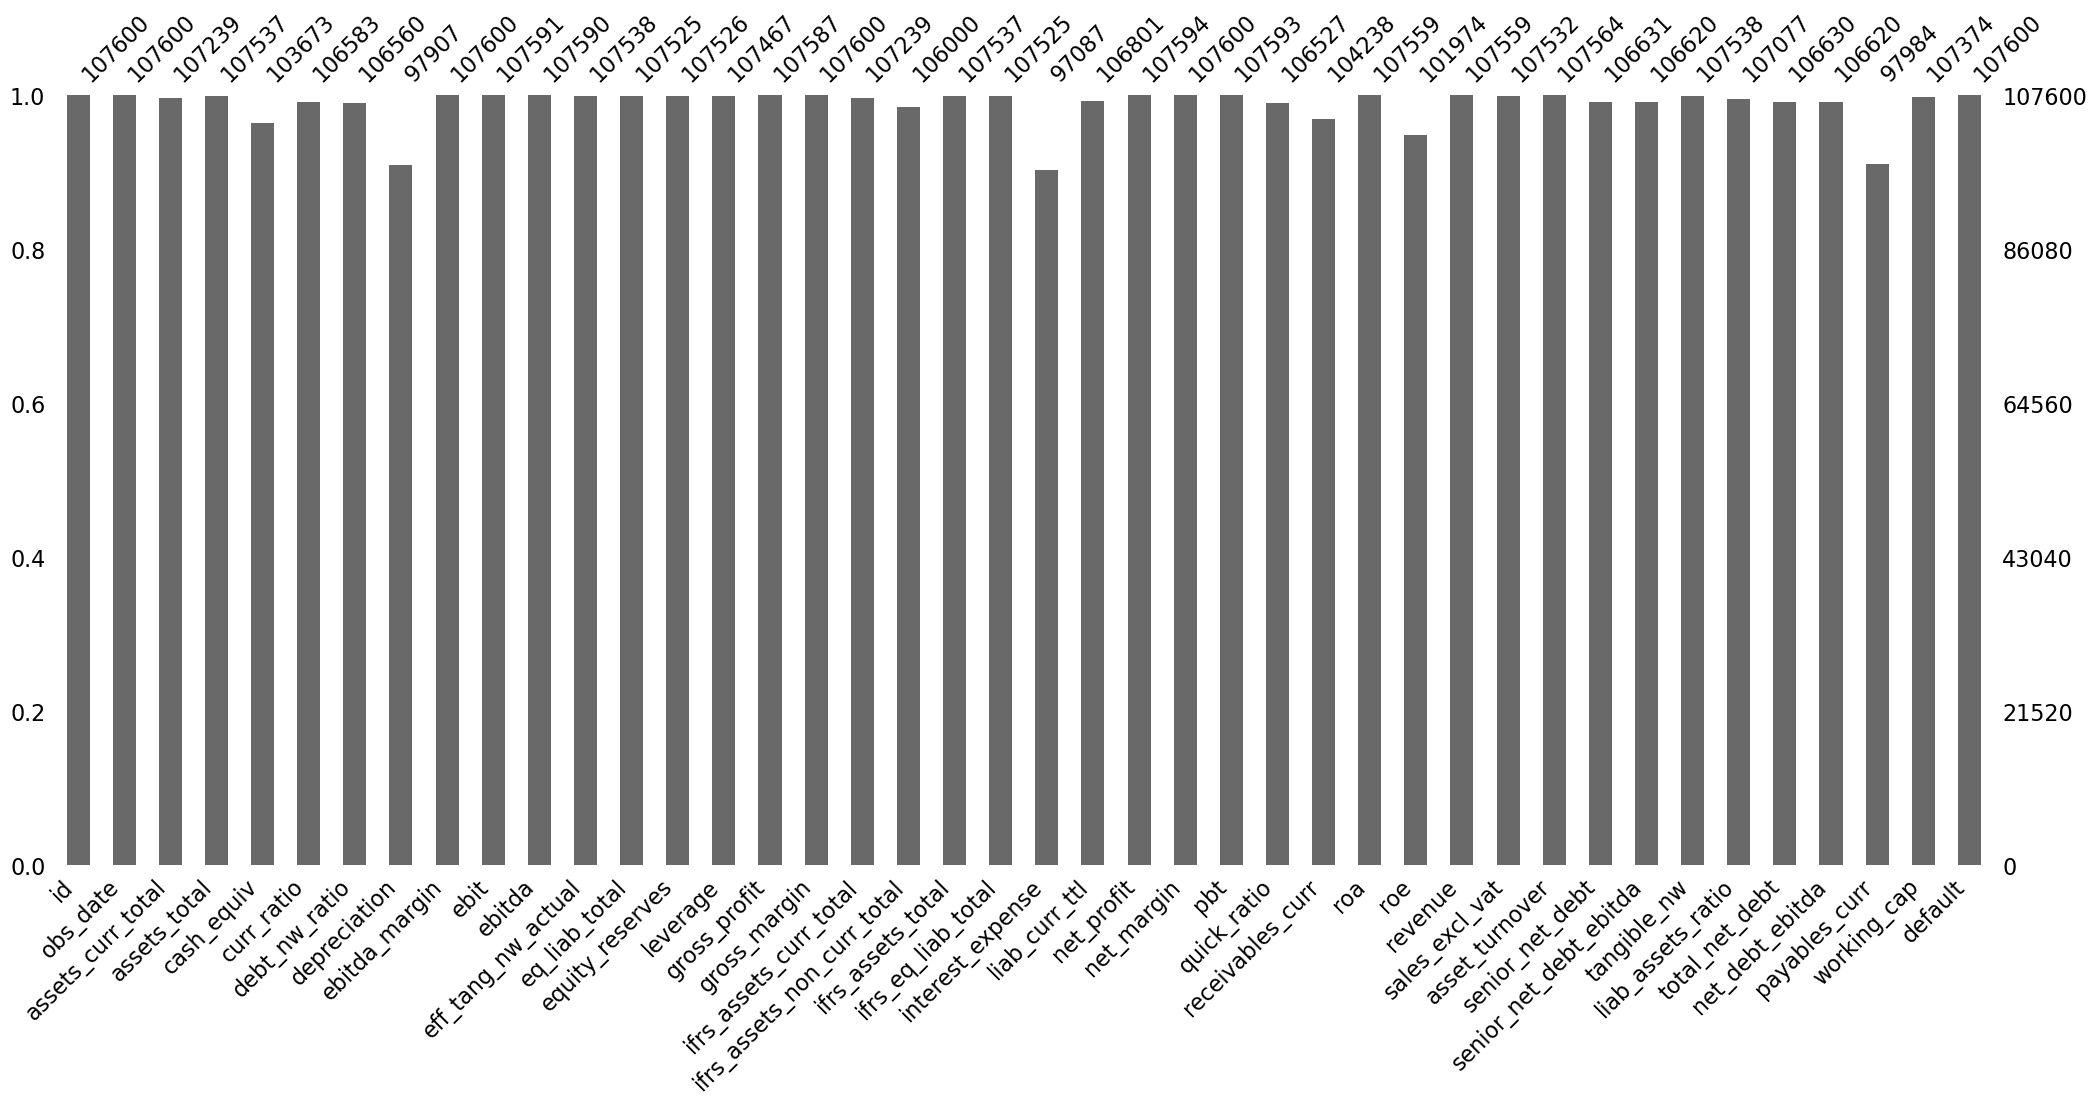

In [46]:
msno.bar(train)

<Axes: >

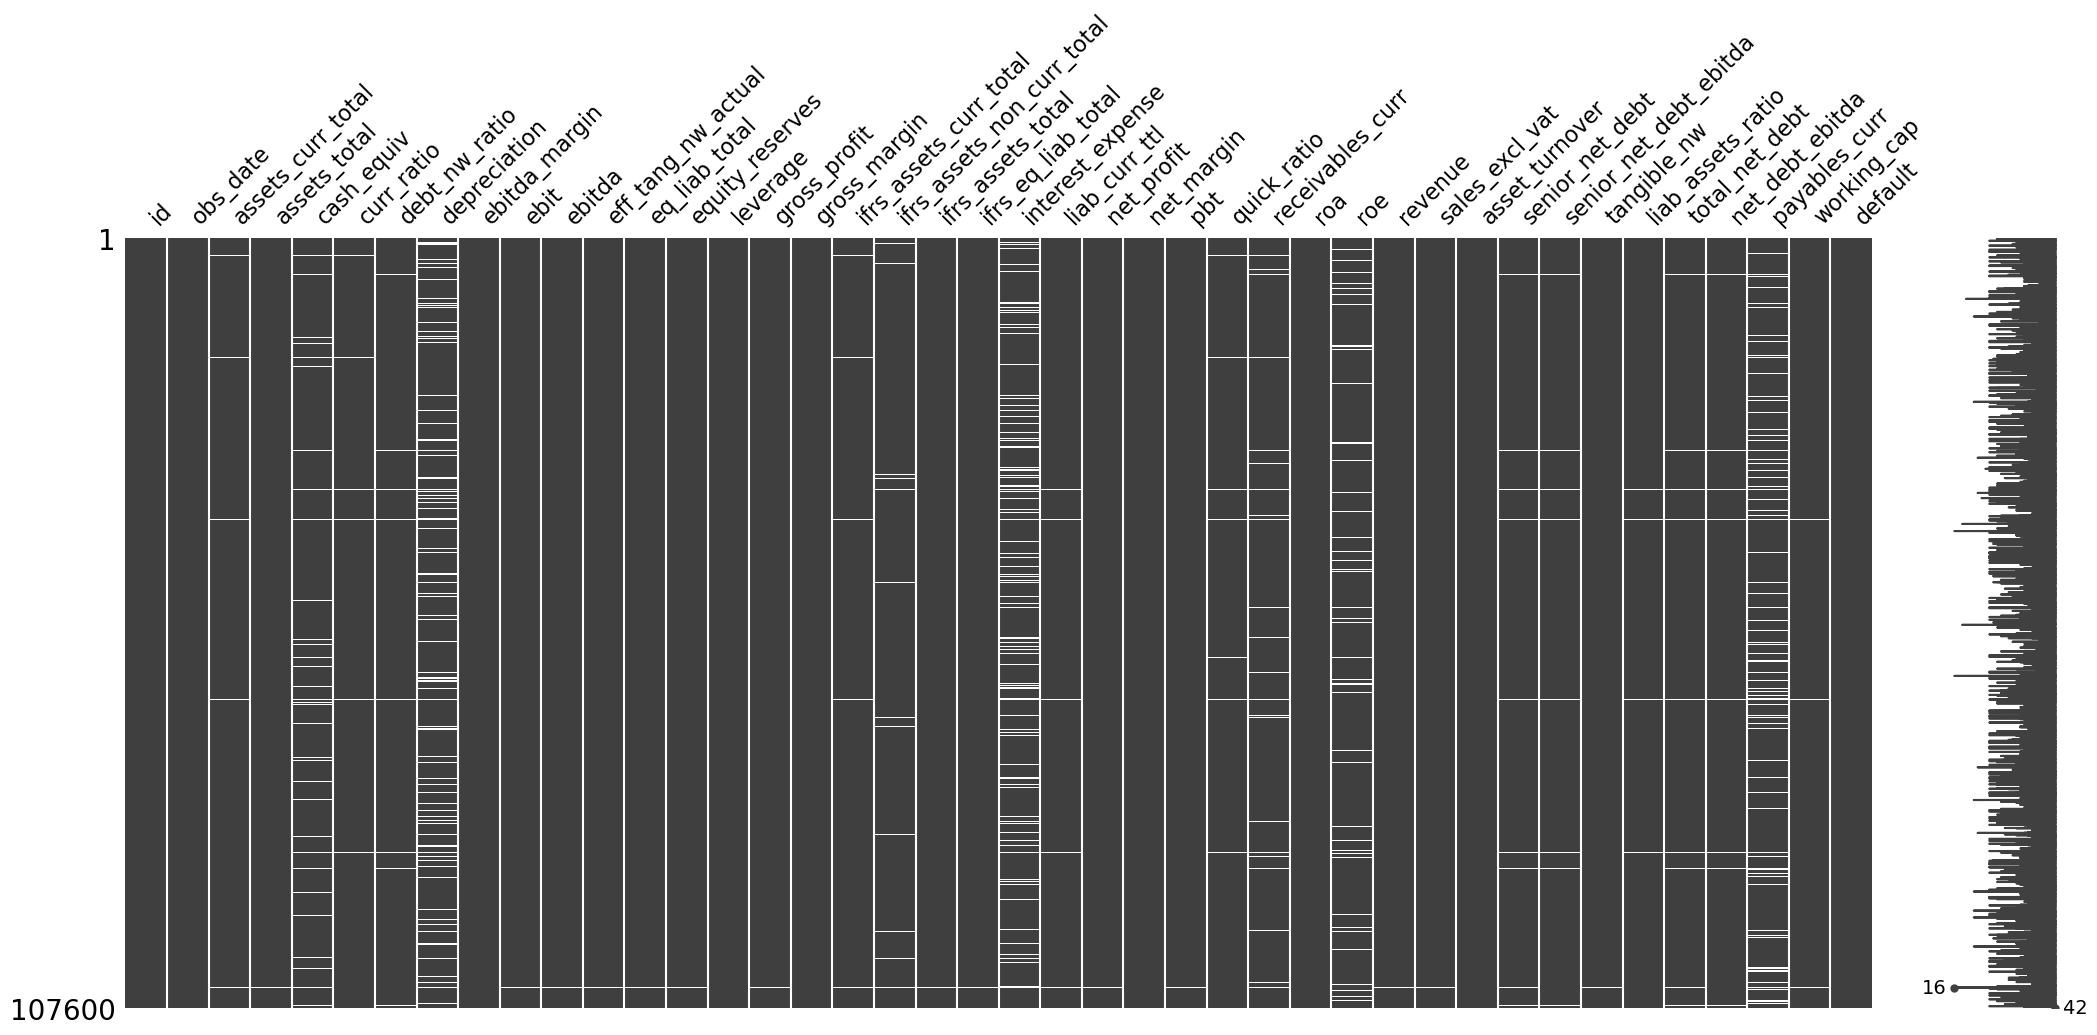

In [17]:
msno.matrix(train)

<Axes: >

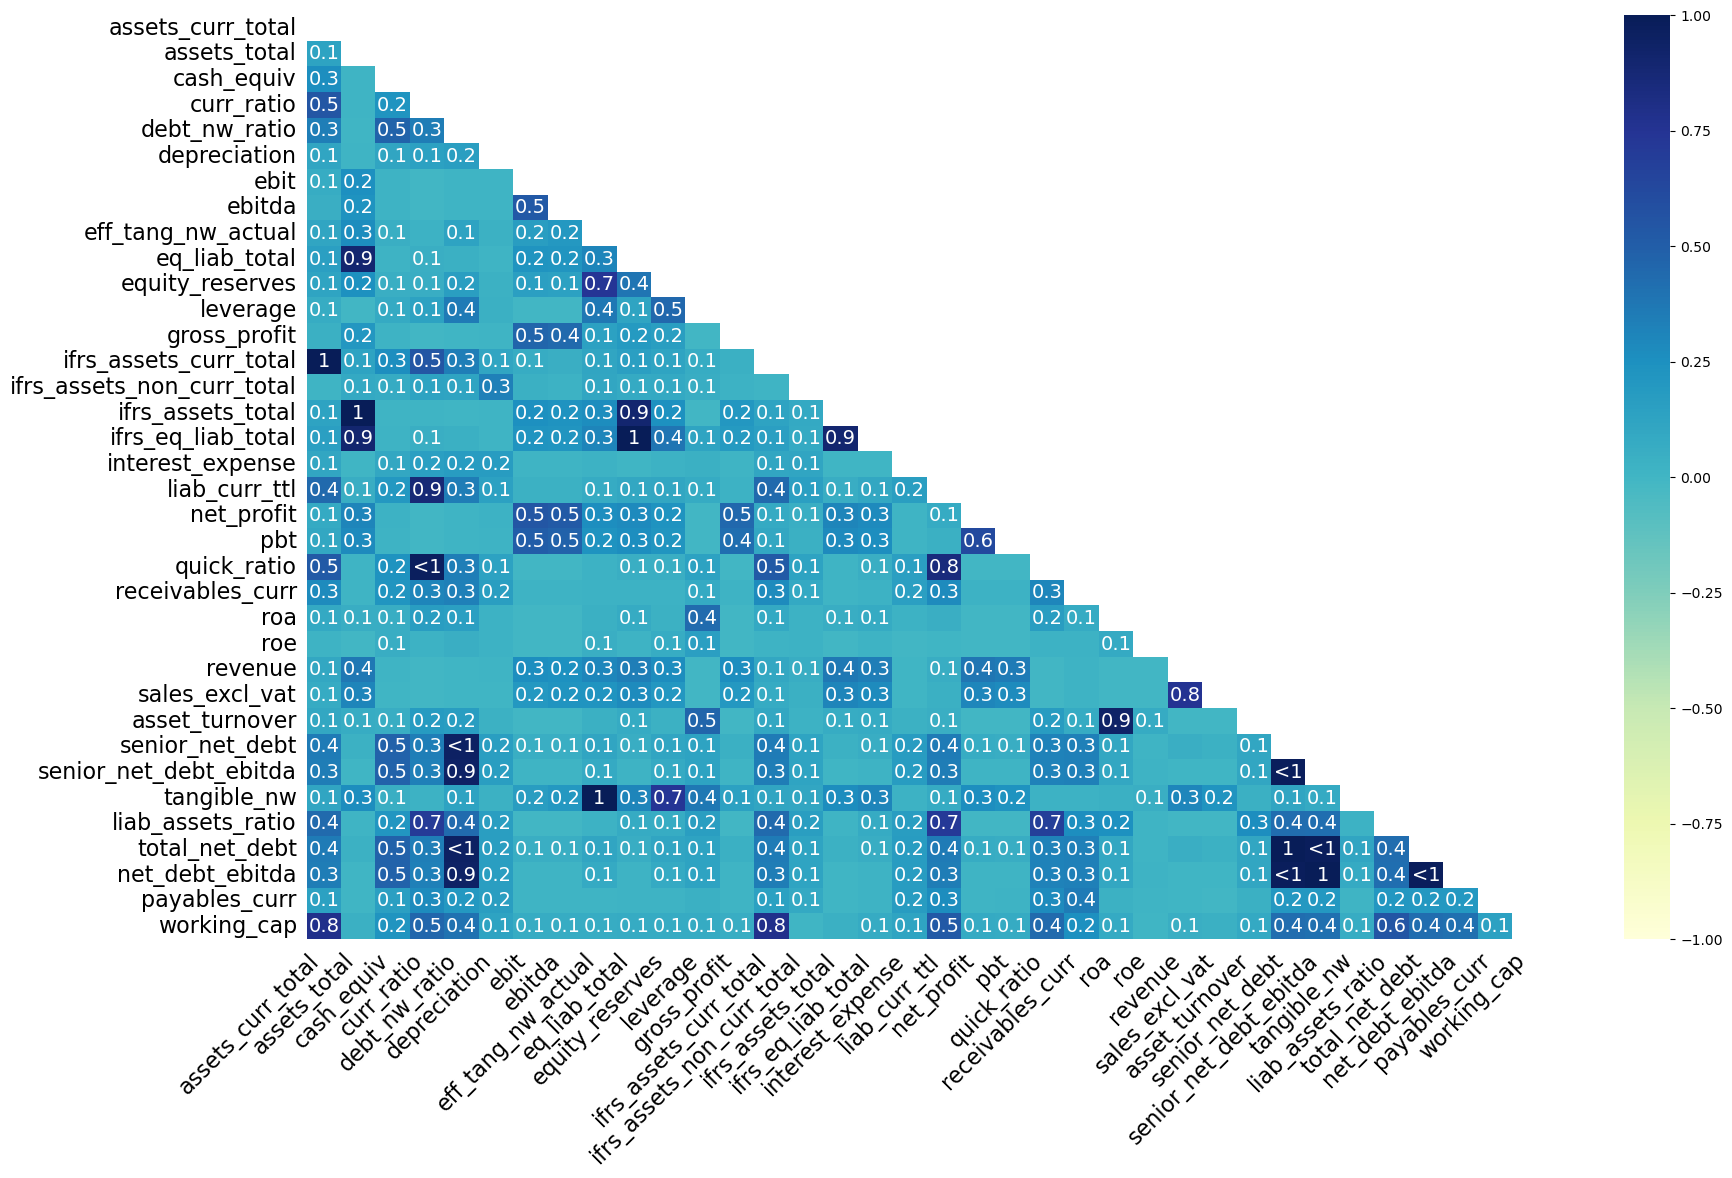

In [18]:
msno.heatmap(train, cmap="YlGnBu")

<Axes: >

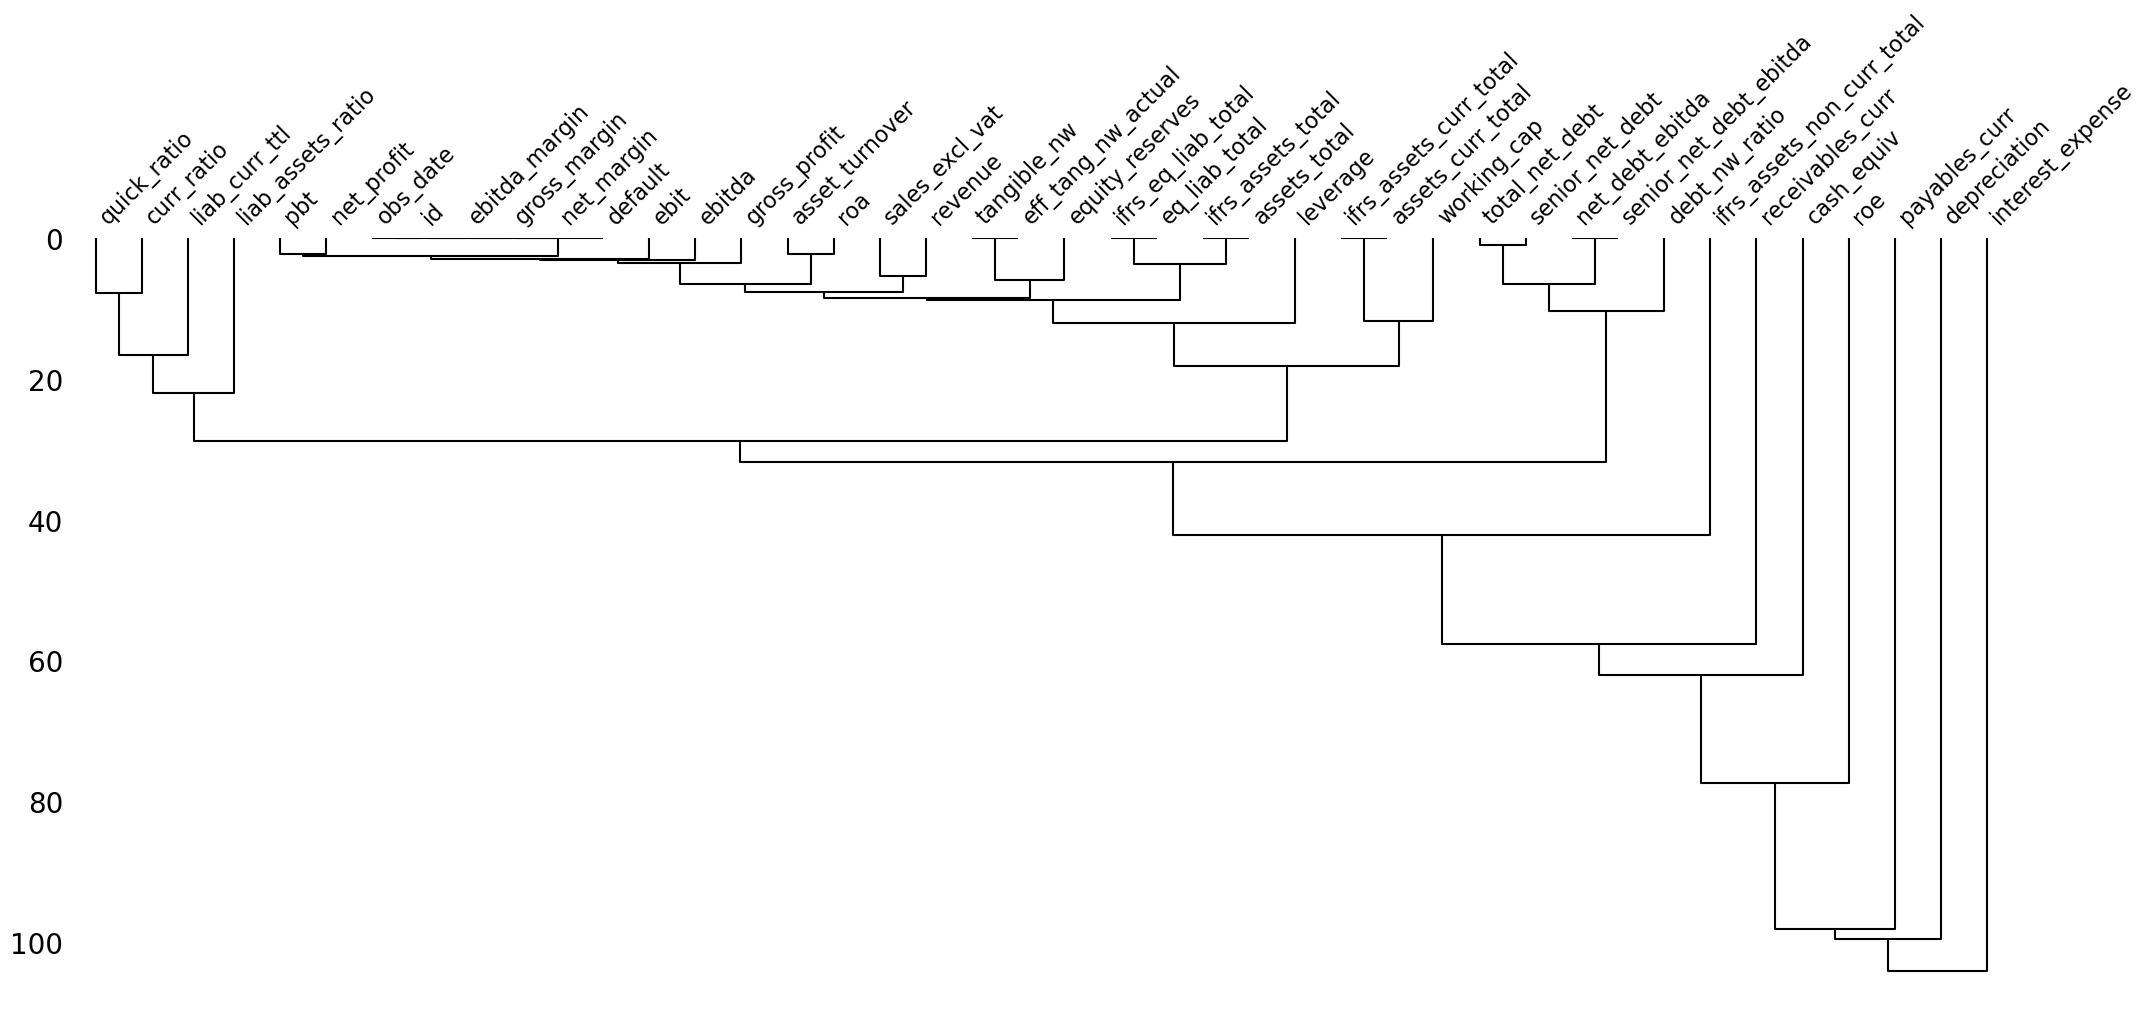

In [19]:
msno.dendrogram(train)

In [20]:
# Diagnostics for the variabes with most missing values 
core_vars = ['assets_total', 'eq_liab_total', 'revenue']
check_vars = ['interest_expense', 'depreciation', 'payables_curr']

print("--- Broader Financial Statement Intactness Check ---")

for var in check_vars:
    missing_subset = train[train[var].isnull()]
    total_missing = len(missing_subset)
    
    print(f"\nEvaluating {total_missing} rows where '{var}' is MISSING:")

    for pillar in core_vars:
        # if it is not null AND greater than zero (a company with 0 assets isn't really an intact financial statement)
        intact_count = missing_subset[missing_subset[pillar] > 0][pillar].count()
        intact_percentage = (intact_count / total_missing) * 100
        
        print(f"  -> {pillar} is intact in: {intact_percentage:.2f}% of these rows.")

print("\n" + "="*50)

--- Broader Financial Statement Intactness Check ---

Evaluating 10513 rows where 'interest_expense' is MISSING:
  -> assets_total is intact in: 99.71% of these rows.
  -> eq_liab_total is intact in: 99.67% of these rows.
  -> revenue is intact in: 99.93% of these rows.

Evaluating 9693 rows where 'depreciation' is MISSING:
  -> assets_total is intact in: 99.66% of these rows.
  -> eq_liab_total is intact in: 99.62% of these rows.
  -> revenue is intact in: 99.91% of these rows.

Evaluating 9616 rows where 'payables_curr' is MISSING:
  -> assets_total is intact in: 99.65% of these rows.
  -> eq_liab_total is intact in: 99.53% of these rows.
  -> revenue is intact in: 99.95% of these rows.



In [21]:
# Diagnostic for Interest Expense
print("--- Profiling Missing Interest Expense ---")
missing_interest = train[train['interest_expense'].isnull()]
present_interest = train[train['interest_expense'].notnull()]

print("Median Debt when Interest is MISSING:")
print(missing_interest[['total_net_debt', 'senior_net_debt']].median())
print("\nMedian Debt when Interest is PRESENT:")
print(present_interest[['total_net_debt', 'senior_net_debt']].median())
print("\n" + "="*40 + "\n")

--- Profiling Missing Interest Expense ---
Median Debt when Interest is MISSING:
total_net_debt               -20072.83
senior_net_debt              -20588.99
dtype: float64

Median Debt when Interest is PRESENT:
total_net_debt               996897.83
senior_net_debt              955448.91
dtype: float64




From the results above we can see that assets_total (99.71%), eq_liab_total (99.67%), and revenue (99.93%) are completely intact for the rows missing interest_expense. Based on that we can ASSUME that the data isn't missing because of a systemic IT failure or corrupted files. The companies filled out their revenue and assets perfectly. They intentionally left interest_expense blank.

Companies missing interest have a median total_net_debt of -$20,072, meaning the company holds more liquid cash than total debt, they are effectively debf-free. Companies reporting interest have a median total_net_debt of $996,897 (Roughly $1 million in debt). It mathematically proves that missing interest is fundamentally tied to a lack of debt. The two groups belong to completely different financial profiles. Additionally, based on the correlation with the missingness, the correlation with other variables is realy weak. The missingness isn't a slow, sliding scale tied to how much revenue a company makes. We can proceed with imputing interest_expense with zeros. 

https://onlinelibrary.wiley.com/doi/10.1111/j.1755-053X.2009.01026.x
https://wrds-www.wharton.upenn.edu/documents/2179/Selected_Questions_Final_-_Answered.pdf

In [22]:
# Diagnostic fr Depreciation
target_var = 'depreciation'
# We check variables that represent physical/fixed assets
related_vars = ['tangible_nw', 'eff_tang_nw_actual', 'assets_total']

missing_df = train[train[target_var].isnull()]
present_df = train[train[target_var].notnull()]

print(f"--- Analyzing Missingness for: {target_var} ---")
print(f"Missing count: {len(missing_df)} | Present count: {len(present_df)}\n")

for var in related_vars:
    print(f"--- Variable: {var} ---")
    median_missing = missing_df[var].median()
    median_present = present_df[var].median()
    print(f"Median (When {target_var} is Missing): {median_missing:.2f}")
    print(f"Median (When {target_var} is Present): {median_present:.2f}")


--- Analyzing Missingness for: depreciation ---
Missing count: 9693 | Present count: 97907

--- Variable: tangible_nw ---
Median (When depreciation is Missing): 12065655.35
Median (When depreciation is Present): 1460443.24
--- Variable: eff_tang_nw_actual ---
Median (When depreciation is Missing): 12404870.29
Median (When depreciation is Present): 1512479.93
--- Variable: assets_total ---
Median (When depreciation is Missing): 84888775.54
Median (When depreciation is Present): 7913147.04


Median tangible_nw when missing is $12 Million. Median tangible_nw when present is $1.4 Million. Median assets_total when missing is $84.8 Million vs $7.9 Million. Our ASSUMPTION is that missing depreciation meant "zero physical assets." The data shows the exact opposite. The companies failing to report depreciation are actually 10 times larger and hold massive amounts of tangible wealth compared to the rest of the dataset. Additionally, we can notice that interest_is_missing has a 0.19 correlation with missing depreciation. This suggests a specific sub-population of large, specialized, or perhaps government-backed entities that just format their income statements differently. In this case, we shouldnt fill missing values with zeros. Because depreciation is clearly tied to the size of the company (Missing Not At Random, but predictable based on assets), we need to use Iterative Imputation (MICE).

In [23]:
# Diagnostic for Payables Current
target_var = 'payables_curr'
# We check variables related to short-term liquidity and debt
related_vars = ['liab_curr_ttl', 'assets_curr_total', 'working_cap']

missing_df = train[train[target_var].isnull()]
present_df = train[train[target_var].notnull()]

print(f"--- Analyzing Missingness for: {target_var} ---")
print(f"Missing count: {len(missing_df)} | Present count: {len(present_df)}\n")

for var in related_vars:
    print(f"--- Variable: {var} ---")
    median_missing = missing_df[var].median()
    median_present = present_df[var].median()
    print(f"Median (When {target_var} is Missing): {median_missing:.2f}")
    print(f"Median (When {target_var} is Present): {median_present:.2f}")

--- Analyzing Missingness for: payables_curr ---
Missing count: 9616 | Present count: 97984

--- Variable: liab_curr_ttl ---
Median (When payables_curr is Missing): 139537.05
Median (When payables_curr is Present): 3988203.44
--- Variable: assets_curr_total ---
Median (When payables_curr is Missing): 253476.52
Median (When payables_curr is Present): 5669477.91
--- Variable: working_cap ---
Median (When payables_curr is Missing): 58738.84
Median (When payables_curr is Present): 400068.71


For the payable_curr we ASSUME it's truly zero when the company operates strictly on cash. Therefore, their overall Current Liabilities (liab_curr_ttl) should be extremely low, and their Current Assets or Working Capital might look very different from a standard business. Median liab_curr_ttl (Total Current Liabilities) when missing is $139,537. Median liab_curr_ttl when present is $3.9 Million. Median assets_curr_total when missing is $253,476 vs $5.6 Million. The companies missing this value are operationally tiny compared to the rest of the dataset. With only $140k in total current liabilities, it is highly probable that their specific short-term trade debt (payables_curr) is exactly zero. We ASSUME they are small businesses operating strictly on a cash basis. They buy supplies with cash upfront rather than opening 30-day invoice accounts with suppliers. The correlation with missing interest_expese is 0.20. Based on out ASSUMPTION, it could confirm a distinct sub-population in the dataset (the debt-free micro-business). Probably, they have no long-term loans (so, they leave interest_expense blank) and they have no short-term supplier credit (so, they leave payables_curr blank). Based on our assumption and conclusion, we would fill payables_curr with zeros. 

In [24]:
# Diagnostic for Receivables Current and Cash Equivalents
tests = {
    'receivables_curr': ['assets_curr_total', 'revenue', 'working_cap'],
    'cash_equiv': ['assets_curr_total', 'assets_total', 'liab_curr_ttl']
}

for target_var, related_vars in tests.items():

    missing_df = train[train[target_var].isnull()]
    present_df = train[train[target_var].notnull()]
    
    print(f"Missing count: {len(missing_df)} | Present count: {len(present_df)}\n")
    
    # 2. Compare Distributions
    for var in related_vars:
        median_missing = missing_df[var].median()
        median_present = present_df[var].median()
        
        stat, p_value = mannwhitneyu(
            missing_df[var].dropna(), 
            present_df[var].dropna(), 
            alternative='two-sided'
        )
        
        print(f"--- Variable: {var} ---")
        print(f"  Median (Missing): {median_missing:,.2f}")
        print(f"  Median (Present): {median_present:,.2f}")

Missing count: 3362 | Present count: 104238

--- Variable: assets_curr_total ---
  Median (Missing): 196,993.12
  Median (Present): 4,427,850.78
--- Variable: revenue ---
  Median (Missing): 511,234.27
  Median (Present): 11,038,890.68
--- Variable: working_cap ---
  Median (Missing): 26,819.65
  Median (Present): 349,691.68
Missing count: 3927 | Present count: 103673

--- Variable: assets_curr_total ---
  Median (Missing): 1,158,277.70
  Median (Present): 4,283,298.76
--- Variable: assets_total ---
  Median (Missing): 4,530,820.93
  Median (Present): 10,571,117.36
--- Variable: liab_curr_ttl ---
  Median (Missing): 902,554.15
  Median (Present): 3,013,323.03


For the receivables_curr the companies missing receivables have notable lower financial footprints. Their median revenue is ~$500k compared to $11 Million, and their current assets are a mere $196k compared to $4.4 Million. The correlation with interest_is_missing is sits at 0.16. This aligns with the profile we found for payables_curr. We ASSSUME these are small, cash-basis operations (like retail shops, restaurants, or micro-services). They don't have Accounts Receivable because they don't issue 30-day invoices to customers. They collect cash/card payments immediately at the point of sale. We can fill missing values with 0. Regarding the cash_equiv, the missing group is smaller than the present group, but they are not micro-businesses. A company missing cash_equiv still has a median assets_total of $4.6 Million and assets_curr_total of over $1.1 Million. It is logically impossible for an active, operating company with $1.1 million in current assets to have literally $0.00 in the bank. So, in this case, we shouldnt fill missing values with zero, we need to use IterativeImputer.

In [25]:
# Diagnostic for ROE
# Isolate rows where ROE is missing
missing_roe = train[train['roe'].isnull()]
total_missing_roe = len(missing_roe)

print(f"--- Analyzing {total_missing_roe} rows with MISSING ROE ---\n")

# Reason 1: Equity is exactly Zero (The Math Error)
# We check if equity is 0 (or incredibly close to 0 due to float rounding)
zero_equity = missing_roe[(missing_roe['eq_liab_total'] >= -1) & (missing_roe['eq_liab_total'] <= 1)]

# Reason 2: Net Profit is missing
missing_profit = missing_roe[missing_roe['net_profit'].isnull()]

# Reason 3: Equity is missing
missing_equity = missing_roe[missing_roe['eq_liab_total'].isnull()]

# Let's see the breakdown
print(f"1. Missing because Equity is exactly 0: {len(zero_equity)} rows")
print(f"2. Missing because Net Profit is missing: {len(missing_profit)} rows")
print(f"3. Missing because Equity is missing: {len(missing_equity)} rows")

# Calculate how many are left over (unexplained missingness)
accounted_for = len(zero_equity) + len(missing_profit) + len(missing_equity)
unexplained = total_missing_roe - accounted_for

print(f"\nUnexplained missing ROE: {unexplained} rows")

if unexplained > 0:
    print("\nLet's profile the 'Unexplained' group...")
    unexplained_df = missing_roe[ 
        ~missing_roe.index.isin(zero_equity.index) & 
        ~missing_roe.index.isin(missing_profit.index) & 
        ~missing_roe.index.isin(missing_equity.index)
    ]
    # Let's see if these unexplained companies have anything in common
    print("Median Total Assets of unexplained:", unexplained_df['assets_total'].median())
    print("Median Net Profit of unexplained:", unexplained_df['net_profit'].median())

--- Analyzing 5626 rows with MISSING ROE ---

1. Missing because Equity is exactly 0: 36 rows
2. Missing because Net Profit is missing: 0 rows
3. Missing because Equity is missing: 15 rows

Unexplained missing ROE: 5575 rows

Let's profile the 'Unexplained' group...
Median Total Assets of unexplained: 3824602.97949029
Median Net Profit of unexplained: 2636.86733929589


We can notice that there are only 36 that actually had a problem of division-by-zero (Equity = 0). That is statisitically insignificant. However, 5,575 companies have entirely unexplained missing ROEs. This look like a system error. We will fill the missing values with iterative imputer as part of the variables with missing values. 

1. Drop IFRS variable (Just different reporting system + could cause multicollinearity) <br>
2. Filling missing values with zeros for the following variables: interest_expense (no debt), payable_curr (cash-basis buying), receivables_curr (cash-basis selling). <br>
3. Filling missing values with systematic Imputation (IterativeImputer/MICE) the following variables: depreciation, roe and cash_equiv. <br>
4. Drop entries with missing values that have less than 1 percent of missingness. 

In [47]:
sklearn.set_config(transform_output="pandas")

# Pre-Processing Function
def initial_cleaner(df):
    df_clean = df.copy()
    
    # Create the Missingness Flags
    flag_cols = ['interest_expense', 'payables_curr', 'receivables_curr', 'depreciation', 'cash_equiv', 'roe']
    for col in flag_cols:
        df_clean[f'{col}_is_missing'] = df_clean[col].isnull().astype(int)

    # Drop Redundant IFRS Columns
    cols_to_drop = ['ifrs_assets_total', 'ifrs_assets_curr_total', 'ifrs_eq_liab_total', 'ifrs_assets_non_curr_total']
    df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

    # Drop Rows with < 1% Missingness
    cols_to_dropna = [
        'debt_nw_ratio', 'net_debt_ebitda', 'senior_net_debt_ebitda', 'total_net_debt', 
        'senior_net_debt', 'curr_ratio', 'quick_ratio', 'liab_curr_ttl', 'liab_assets_ratio', 
        'assets_curr_total', 'working_cap', 'leverage', 'equity_reserves', 'eq_liab_total', 
        'tangible_nw', 'eff_tang_nw_actual', 'assets_total', 'sales_excl_vat', 'roa', 
        'revenue', 'asset_turnover', 'gross_profit', 'ebitda', 'ebit', 'pbt', 'net_profit'
    ]
    df_clean = df_clean.dropna(subset=cols_to_dropna)
    
    return df_clean

# Apply cleaning to all three datasets
print("Cleaning initial datasets...")
train_clean = initial_cleaner(train)
val_clean = initial_cleaner(validate)
test_clean = initial_cleaner(test)


# Separate Features (X) from Meta/Target Data
meta_cols = ['id', 'obs_date', 'default']

X_train = train_clean.drop(columns=meta_cols)
X_val = val_clean.drop(columns=meta_cols)
X_test = test_clean.drop(columns=meta_cols)

# Run the Imputation Pipeline
zero_fill_cols = ['interest_expense', 'payables_curr', 'receivables_curr']
mice_cols = [col for col in X_train.columns if col not in zero_fill_cols and not col.endswith('_is_missing')]

preprocessor = ColumnTransformer(
    transformers=[
        ('zero_imputer', SimpleImputer(strategy='constant', fill_value=0), zero_fill_cols),
        ('mice_imputer', IterativeImputer(random_state=42, max_iter=10), mice_cols)
    ],
    remainder='passthrough'
)

print("\nFitting the Imputation Pipeline on Train data (this will take a minute)...")
X_train_imputed = preprocessor.fit_transform(X_train)

print("Transforming Val and Test data...")
X_val_imputed = preprocessor.transform(X_val)
X_test_imputed = preprocessor.transform(X_test)


#  Re-attach Target & IDs, then Export to CSV
# https://www.geeksforgeeks.org/machine-learning/handling-missing-data-with-iterativeimputer-in-scikit-learn/
train_final = pd.concat([X_train_imputed, train_clean[meta_cols]], axis=1)
val_final = pd.concat([X_val_imputed, val_clean[meta_cols]], axis=1)
test_final = pd.concat([X_test_imputed, test_clean[meta_cols]], axis=1)

train_final.columns = train_final.columns.str.split('__').str[-1]
val_final.columns = val_final.columns.str.split('__').str[-1]
test_final.columns = test_final.columns.str.split('__').str[-1]

output_folder = "Final_Processed_Datasets"
os.makedirs(output_folder, exist_ok=True)

datasets = {
    'train_processed.csv': train_final,
    'val_processed.csv': val_final,
    'test_processed.csv': test_final
}

for name, data in datasets.items():
    path = os.path.join(output_folder, name)
    
    if os.path.exists(path):
        os.remove(path)
        print(f"Rewriting '{name}' file")
    else:
        print(f"No existing file found. Creating '{name}' for the first time.")
        
    data.to_csv(path, index=False, sep=';')
    print(f"Saved {name}: {data.shape}\n")

Cleaning initial datasets...

Fitting the Imputation Pipeline on Train data (this will take a minute)...


C:\Users\ydmar\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Transforming Val and Test data...
Rewriting 'train_processed.csv' file
Saved train_processed.csv: (105643, 44)

Rewriting 'val_processed.csv' file
Saved val_processed.csv: (18665, 44)

Rewriting 'test_processed.csv' file
Saved test_processed.csv: (21945, 44)



In [27]:
num_missing = train_final.isna().sum()
num_missing = num_missing[num_missing > 0]
percent_missing = num_missing * 100 / train_final.shape[0]
pd.concat([num_missing, percent_missing], axis=1, 
          keys=['Missing Values', 'Percentage']).\
          sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage


In [28]:
num_missing = val_final.isna().sum()
num_missing = num_missing[num_missing > 0]
percent_missing = num_missing * 100 / val_final.shape[0]
pd.concat([num_missing, percent_missing], axis=1, 
          keys=['Missing Values', 'Percentage']).\
          sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage


In [29]:
num_missing = test_final.isna().sum()
num_missing = num_missing[num_missing > 0]
percent_missing = num_missing * 100 / test_final.shape[0]
pd.concat([num_missing, percent_missing], axis=1, 
          keys=['Missing Values', 'Percentage']).\
          sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage


In [30]:
train.describe(include=[np.number], percentiles=[.5]) \
    .transpose().drop("count", axis=1)

,mean,std,min,50%,max
id,50405527.49,28989910.16,1574.00,50744300.00,99992121.00
assets_curr_total,35360235817.23,766803328501.85,0.00,4040766.31,68499002287834.80
assets_total,82752049975.66,1388498944767.49,0.00,9986480.98,98363802053935.30
cash_equiv,13539084312.25,532422574434.75,0.00,440252.63,80342649852952.09
curr_ratio,232.38,67545.63,0.00,1.40,21963070.70
debt_nw_ratio,-163.56,2277882.73,-697025081.19,0.25,154913776.71
depreciation,5647421730.69,183329249254.65,0.00,226521.58,31067952953619.50
ebitda_margin,2810.15,597502.26,-280937.00,0.12,163321856.00
ebit,8349912479.42,348413476835.37,-19863564771907.50,349528.54,44344145869836.20
ebitda,13328251020.74,474883600075.12,-16152933827531.50,678432.60,69918159134340.20


A distributional analysis of the post-imputation data revealed extreme right-skewness across almost all financial variables. For instance, the median assets_total was approximately $10.1M, but the maximum recorded value was $95 Trillion. Similarly, calculation errors in the raw data resulted in mathematically impossible ratios, such as a maximum Return on Equity (ROE) of 142 Million. To neutralize this, a 1% / 99% Winsorization strategy could be applied applied. Extreme values below the 1st percentile and above the 99th percentile could be capped at those respective thresholds.

In [48]:
# Isolate the columns (ignoring targets, dates, and flags)
cols_to_skip = ['id', 'obs_date', 'default']
flag_cols = [col for col in train_final.columns if col.endswith('_is_missing')]
cols_to_winsorize = [col for col in train_final.columns if col not in cols_to_skip and col not in flag_cols]

summary_list = []

for col in cols_to_winsorize:
    floor = train_final[col].quantile(0.01)
    ceiling = train_final[col].quantile(0.99)
    current_min = train_final[col].min()
    current_max = train_final[col].max()
    
    summary_list.append({
        'Feature': col,
        'Current Min': current_min,
        'Proposed 1% Floor': floor,
        'Proposed 99% Ceiling': ceiling,
        'Current Max': current_max
    })

winsor_check_df = pd.DataFrame(summary_list)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_rows', 50) 

print("--- PROPOSED WINSORIZATION THRESHOLDS ---")
print(winsor_check_df)
pd.reset_option('display.float_format')

--- PROPOSED WINSORIZATION THRESHOLDS ---
                   Feature            Current Min  Proposed 1% Floor  \
0         interest_expense                   0.00               0.00   
1            payables_curr                   0.00               0.00   
2         receivables_curr                   0.00               0.00   
3        assets_curr_total                   0.00           8,439.35   
4             assets_total                   2.56          22,571.17   
5               cash_equiv      -4,147,178,668.49     -71,369,770.13   
6               curr_ratio                   0.00               0.09   
7            debt_nw_ratio        -697,025,081.19             -14.19   
8             depreciation -38,787,388,818,919.33             325.24   
9            ebitda_margin            -280,937.00              -0.53   
10                    ebit  -1,458,322,913,914.44    -233,721,902.41   
11                  ebitda  -1,128,428,399,890.12     -44,290,040.57   
12      eff_tang_nw_ac

In [ ]:
print(f"Applying Winsorization (1st & 99th Percentile) to {len(cols_to_winsorize)} columns...\n")

# Apply the caps learned strictly from Train
for col in cols_to_winsorize:
    floor = train_final[col].quantile(0.01)
    ceiling = train_final[col].quantile(0.99)
    
    train_final[col] = np.clip(train_final[col], floor, ceiling)
    val_final[col] = np.clip(val_final[col], floor, ceiling)
    test_final[col] = np.clip(test_final[col], floor, ceiling)

print("Winsorization complete")
output_folder = "Final_Processed_Datasets"
datasets = {
    'train_processed.csv': train_final,
    'val_processed.csv': val_final,
    'test_processed.csv': test_final
}

for name, data in datasets.items():
    path = os.path.join(output_folder, name)
    
    if os.path.exists(path):
        os.remove(path)
        print(f"Rewriting '{name}' file")
    else:
        print(f"No existing file found. Creating '{name}' for the first time.")
        
    data.to_csv(path, index=False, sep=';')
    print(f"Saved {name}: {data.shape}\n")

print("Files were overwritten and saved")

In [51]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
train_final.describe(include=[np.number], percentiles=[.5]) \
    .transpose().drop("count", axis=1)

,mean,std,min,50%,max
interest_expense,"115,476,869.97","679,469,923.84",0.00,"59,814.49","5,991,095,168.26"
payables_curr,"1,194,016,803.12","7,201,228,510.26",0.00,"566,257.82","63,879,702,183.10"
receivables_curr,"1,418,850,901.76","8,370,861,154.63",0.00,"1,394,129.01","73,987,751,402.33"
assets_curr_total,"4,488,493,377.56","26,943,201,669.00","8,439.35","4,091,897.05","239,647,306,146.52"
assets_total,"12,350,799,606.73","73,669,914,823.07","22,571.17","10,237,921.91","651,922,459,296.38"
cash_equiv,"987,491,290.18","6,146,720,494.69","-71,369,770.13","394,109.84","54,759,362,603.35"
curr_ratio,2.48,4.01,0.09,1.40,30.57
debt_nw_ratio,0.83,4.11,-14.19,0.25,28.60
depreciation,"3,652,771,050.16","10,930,302,267.67",325.24,"367,682.24","39,671,282,200.67"
ebitda_margin,0.20,0.24,-0.53,0.12,0.99
